In [1]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Data Loading

In [2]:
class CellDataset(Dataset):
    def __init__(self, img_path, label_path):
        self.images = np.load(img_path)[:, 0, :, :]  # Select only the first time point
        self.labels = np.load(label_path)
    

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((20, 20)),  # Ensure images are correctly sized
            # transforms.Normalize(mean=[0.5], std=[0.5])  # One channel only
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (H, W)
        label = self.labels[idx]

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Add channel dim (1, 20, 20)
        return img, label

# Load the data
dataset = CellDataset(
    img_path='lung_cancer_data/time_norm_train_images.npy',
    label_path='lung_cancer_data/train_labels_augmented4.npy'
)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 69


In [3]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2184
Number of batches in DataLoader: 69


In [4]:
img, label = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([1, 20, 20])
Image max value: 0.5869320034980774
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2184


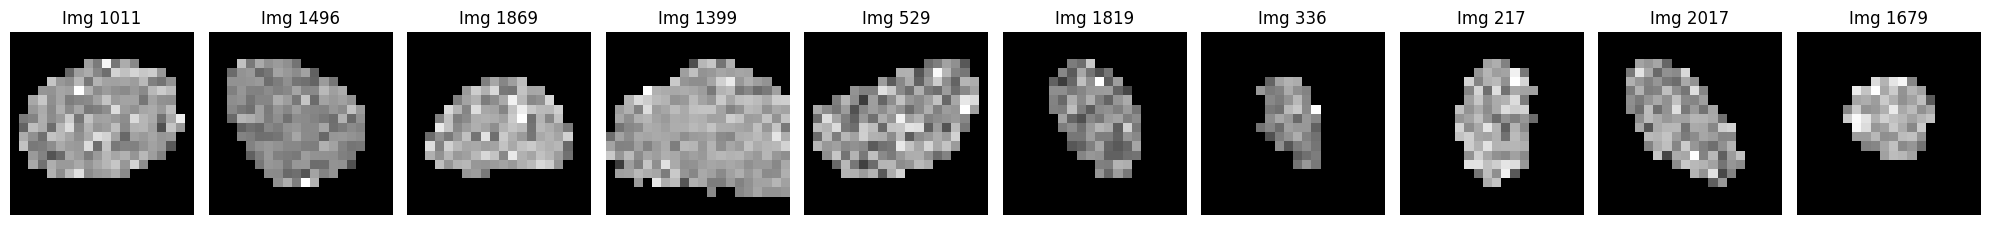

In [5]:
# Randomly select 10 indices
indices = np.random.choice(len(dataset), 10, replace=False)

# Create figure with 1 row and 10 columns (since there's only 1 channel)
fig, axes = plt.subplots(1, 10, figsize=(20, 5))

for i, idx in enumerate(indices):
    img, _ = dataset[idx]  # Get image and ignore labels
    img = img.numpy()  # Convert tensor to numpy array

    # Display the single-channel image
    axes[i].imshow(img[0], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Img {idx}")

plt.tight_layout()
plt.show()

# Data Visualisation functions

In [6]:
def visualize_reconstructions(vae, dataloader, device):
    """
    Visualizes original and reconstructed images from the VAE.
    Adapted for 1-channel (grayscale) 20x20 images.
    Displays 5 examples in a 2-row grid:
      - Top row: original images.
      - Bottom row: corresponding reconstructions.
    """
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)

            # Create a 2x5 grid: original on top, reconstruction below
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):  # Show 5 images
                # Original image (channel 0, since we have one channel)
                img_orig = images[i, 0].cpu().numpy()
                ax = axes[0, i]
                im = ax.imshow(img_orig, cmap="gray")
                ax.set_title("Original")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

                # Reconstructed image
                img_recon = recon_images[i, 0].cpu().numpy()
                ax = axes[1, i]
                im = ax.imshow(img_recon, cmap="gray")
                ax.set_title("Reconstructed")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            plt.tight_layout()
            plt.show()
            break  # Only visualize the first batch

In [7]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for all data points in the dataloader 
    and creates a scatter plot of the latent space colored by binary labels.
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            # Obtain latent variables via the encoder
            mu, logvar = vae.encode(images)
            z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
            all_zs.append(z.cpu().numpy())
            all_labels.append(labels.numpy() if hasattr(labels, 'numpy') else np.array(labels))

    # Concatenate arrays from all batches
    all_zs = np.vstack(all_zs)
    all_labels = np.hstack(all_labels)

    # Define fixed dark colors for each label (modify as desired)
    unique_labels = np.unique(all_labels)
    label_color_map = {
        unique_labels[0]: "#003366",  # Dark Navy Blue
        unique_labels[1]: "#FF4500"   # Dark Orange-Red
    }

    plt.figure(figsize=(8, 6))
    for label in unique_labels:
        mask = np.where(all_labels == label)[0]
        if len(mask) > 0:
            plt.scatter(all_zs[mask, 0], all_zs[mask, 1],
                        color=label_color_map[label], label=f"Label {label}",
                        alpha=0.7, s=10)
    plt.title('Latent Space (Unbalanced Data)')
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend(title="Labels", loc="best")
    plt.tight_layout()
    plt.show()


## Model with 4 layers:

In [ ]:
class VAE_MP4(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP4, self).__init__()

        self.final_size = 2
        self.flat_dim = 256 * self.final_size * self.final_size  # 256 * 2 * 2 = 1024

        # ---------------------
        # Encoder: 4 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 2: 10x10 → 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 3: 5x5 → 3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1),  

            # Block 4: 3x3 → 2x2
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)  
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 4 Blocks with ConvTranspose2d
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 2x2 → 3x3
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample from 3x3 → 5x5
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 3: Upsample from 5x5 → 10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 4: Upsample from 10x10 → 20x20
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()  # Output in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)  # Expected shape: (batch, 256, 2, 2)
        h_flat = h.view(-1, self.flat_dim)  # Flatten to (batch, 1024)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)  # (batch, 1024)
        h = h_flat.view(-1, 256, self.final_size, self.final_size)  # (batch, 256, 2, 2)
        x_recon = self.decoder(h)  # Expected output shape: (batch, 1, 20, 20)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

## Model with 3 layers:

### Max channel size: 128

In [11]:
class VAE_MP3_128(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP3_128, self).__init__()

        self.final_size = 3  # 20 → 10 → 5 → 3
        self.flat_dim = 128 * self.final_size * self.final_size  # 128 * 3 * 3 = 1152

        # ---------------------
        # Encoder: 3 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 10x10 → 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 5x5 → 3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)  # Final size ~3x3
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 3 Blocks with ConvTranspose2d
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 3x3 → 5x5
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample from 5x5 → 10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 3: Upsample from 10x10 → 20x20
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()  # Ensures outputs are in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)  # Expected shape: (batch, 128, 3, 3)
        h_flat = h.view(-1, self.flat_dim)  # Flatten to (batch, 1152)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)  # (batch, 1152)
        h = h_flat.view(-1, 128, self.final_size, self.final_size)  # Reshape to (batch, 128, 3, 3)
        x_recon = self.decoder(h)  # Expected output shape: (batch, 1, 20, 20)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


### Max channel size: 256

In [12]:
class VAE_MP3_256(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP3_256, self).__init__()

        self.final_size = 3  # 20 → 10 → 5 → 3
        self.flat_dim = 128 * self.final_size * self.final_size  # 128 * 3 * 3 = 1152

        # ---------------------
        # Encoder: 3 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 2: 10x10 → 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 3: 5x5 → 3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)  # End at 3x3
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.final_size = 3  # 20 → 10 → 5 → 3
        self.flat_dim = 256 * self.final_size * self.final_size  # 256 * 3 * 3 = 2304

        # ---------------------
        # Encoder: 3 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 10x10 → 5x5
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 5x5 → 3x3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=1)  # End at 3x3
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 3 Blocks with ConvTranspose2d
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 3x3 → 5x5
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample from 5x5 → 10x10
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 3: Upsample from 10x10 → 20x20
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()  # Output in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)  # Expected shape: (batch, 256, 3, 3)
        h_flat = h.view(-1, self.flat_dim)  # Flatten to (batch, 2304)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)  # (batch, 2304)
        h = h_flat.view(-1, 256, self.final_size, self.final_size)  # Reshape to (batch, 256, 3, 3)
        x_recon = self.decoder(h)  # Expected output shape: (batch, 1, 20, 20)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

## Model with 2 layers:

### Max channel size: 64

In [8]:
class VAE_MP2_64(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP2_64, self).__init__()
        
        # Final feature map size after 2 downsampling steps: 20 → 10 → 5
        self.final_size = img_size // 4  # 20 // 4 = 5
        self.flat_dim = 64 * self.final_size * self.final_size  # 64 * 5 * 5 = 1600

        # ---------------------
        # Encoder: 2 Blocks (Conv → ReLU → MaxPool)
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 10x10 → 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 2 Blocks (ConvTranspose → ReLU), then Final Upsample
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample 5x5 → 10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample 10x10 → 20x20
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU()  # Matches original MP4 final activation (then upsample)
        )

        # Final Upsample to ensure exactly (batch, 1, 20, 20)
        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)

    def encode(self, x):
        """Encode the input into latent parameters (mu, logvar)."""
        h = self.encoder(x)  # (batch, 64, 5, 5)
        h_flat = h.view(-1, self.flat_dim)  # (batch, 1600)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick to sample z."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector z back to an image."""
        h_flat = self.fc_decode(z)  # (batch, 1600)
        h = h_flat.view(-1, 64, self.final_size, self.final_size)  # (batch, 64, 5, 5)
        x_recon = self.decoder(h)  # ~ (batch, 1, 20, 20)
        x_recon = self.final_upsample(x_recon)  # Force exact 20x20 if there's any offset
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


### MAx channel size: 128

In [8]:
class VAE_MP2_128(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP2_128, self).__init__()

        self.final_size = 5  # 20 → 10 → 5
        self.flat_dim = 128 * self.final_size * self.final_size  # Increased to 128 channels

        # ---------------------
        # Encoder: 2 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 64, kernel_size=3, padding=1),  # Increased to 64 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 2: 10x10 → 5x5
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Increased to 128 channels
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 2 Blocks with ConvTranspose2d
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 5x5 → 10x10
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample from 10x10 → 20x20
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()  # Output in [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)  # Expected shape: (batch, 128, 5, 5)
        h_flat = h.view(-1, self.flat_dim)  # Flatten to (batch, 3200)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)  # (batch, 3200)
        h = h_flat.view(-1, 128, self.final_size, self.final_size)  # Reshape to (batch, 128, 5, 5)
        x_recon = self.decoder(h)  # Expected output shape: (batch, 1, 20, 20)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [9]:
# Instantiate the model for 20x20 images with 1 channel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = VAE_MP2_64(img_channels=1, latent_dim=2, img_size=20).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#print(model)
#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [10]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    #kl_divergence = kl_divergence

    return reconstruction_loss, kl_divergence

In [11]:
# Print number of trainable parameters
print(f"Number of trainable parameters: {sum(p.numel() for p in vae.parameters() if p.requires_grad)}")

Number of trainable parameters: 63333


In [12]:
# Assuming you have already defined your VAE_MP4 class and instantiated your model, e.g.:
# vae = VAE_MP4(img_channels=2, latent_dim=10, img_size=140).to(device)

# Dictionary to store activations (if you want to use them later)
activations = {}

def get_activation(name):
    def hook(module, input, output):
        # Count active units as the number of elements > 0
        if isinstance(output, torch.Tensor):
            active_units = (output > 0).sum().item()
            #print(f"Layer '{name}' ({module.__class__.__name__}): active units = {active_units}")
            activations[name] = active_units
    return hook

# Register hooks for all leaf modules (modules that do not have child modules)
for name, module in vae.named_modules():
    if not list(module.children()):
        module.register_forward_hook(get_activation(name))

# Create a dummy input (adjust batch size if needed)
dummy_input = torch.randn(1, 1, 20, 20).to(device)

# Run a forward pass to trigger the hooks and print out active units
_ = vae(dummy_input)


## Train without weights:

In [12]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 50
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(data_loader, unit="batch") as tepoch:
        for batch_idx, (images, _) in enumerate(tepoch):  # Updated unpacking to match CellDataset
            tepoch.set_description(f"Epoch {epoch+1}")

            images = images.to(device)
            
            # Print shape of images before input to the VAE
            #print(f"Batch {batch_idx}: Training Data Shape: {images.shape}")  # Expect (batch_size, 1, 20, 20)

            optimizer.zero_grad()  # Zero gradients
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            
            # Print shape of latent space
            #print(f"Batch {batch_idx}: Latent Space Shape (mu): {mu.shape}")    # Expect (batch_size, latent_dim)
            #print(f"Batch {batch_idx}: Latent Space Shape (logvar): {logvar.shape}")  # Expect (batch_size, latent_dim)
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            
            # Final loss = Only reconstruction loss (NO KL weight)
            total_loss = recon_loss + kl_loss 
            
            total_loss.backward()  # Backward pass
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1)  # Gradient clipping
            
            optimizer.step()  # Optimizer step
            
            # Accumulate losses for the epoch
            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=total_loss.item()
            )

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(data_loader)
    avg_recon_loss = epoch_recon_loss / len(data_loader)
    avg_kl_loss = epoch_kl_loss / len(data_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(data_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


  0%|          | 0/69 [00:00<?, ?batch/s]

Epoch 1: 100%|██████████| 69/69 [00:05<00:00, 12.76batch/s, kl_loss=0.747, recon_loss=45, total_loss=45.7]


Epoch 1: Loss = 0.1469


Epoch 2: 100%|██████████| 69/69 [00:03<00:00, 18.21batch/s, kl_loss=4.57, recon_loss=53.2, total_loss=57.8]


Epoch 2: Loss = 0.0987


...

Epoch 48: Loss = 0.0844


Epoch 49: 100%|██████████| 69/69 [00:04<00:00, 15.79batch/s, kl_loss=6.65, recon_loss=41.3, total_loss=48]


Epoch 49: Loss = 0.0847


Epoch 50: 100%|██████████| 69/69 [00:04<00:00, 15.66batch/s, kl_loss=8.73, recon_loss=48.7, total_loss=57.4]


Epoch 50: Loss = 0.0846


## MP3_128 with beta = 1 and 50 epochs:

Layer 'encoder.0' (Conv2d): active units = 154877
Layer 'encoder.1' (ReLU): active units = 154877
Layer 'encoder.2' (MaxPool2d): active units = 46113
Layer 'encoder.3' (Conv2d): active units = 23442
Layer 'encoder.4' (ReLU): active units = 23442
Layer 'encoder.5' (MaxPool2d): active units = 8393
Layer 'encoder.6' (Conv2d): active units = 12660
Layer 'encoder.7' (ReLU): active units = 12660
Layer 'encoder.8' (MaxPool2d): active units = 6955
Layer 'fc_mu' (Linear): active units = 34
Layer 'fc_logvar' (Linear): active units = 0
Layer 'fc_decode' (Linear): active units = 18580
Layer 'decoder.0' (ConvTranspose2d): active units = 21831
Layer 'decoder.1' (ReLU): active units = 21831
Layer 'decoder.2' (ConvTranspose2d): active units = 39856
Layer 'decoder.3' (ReLU): active units = 39856
Layer 'decoder.4' (ConvTranspose2d): active units = 0
Layer 'decoder.5' (Sigmoid): active units = 12800


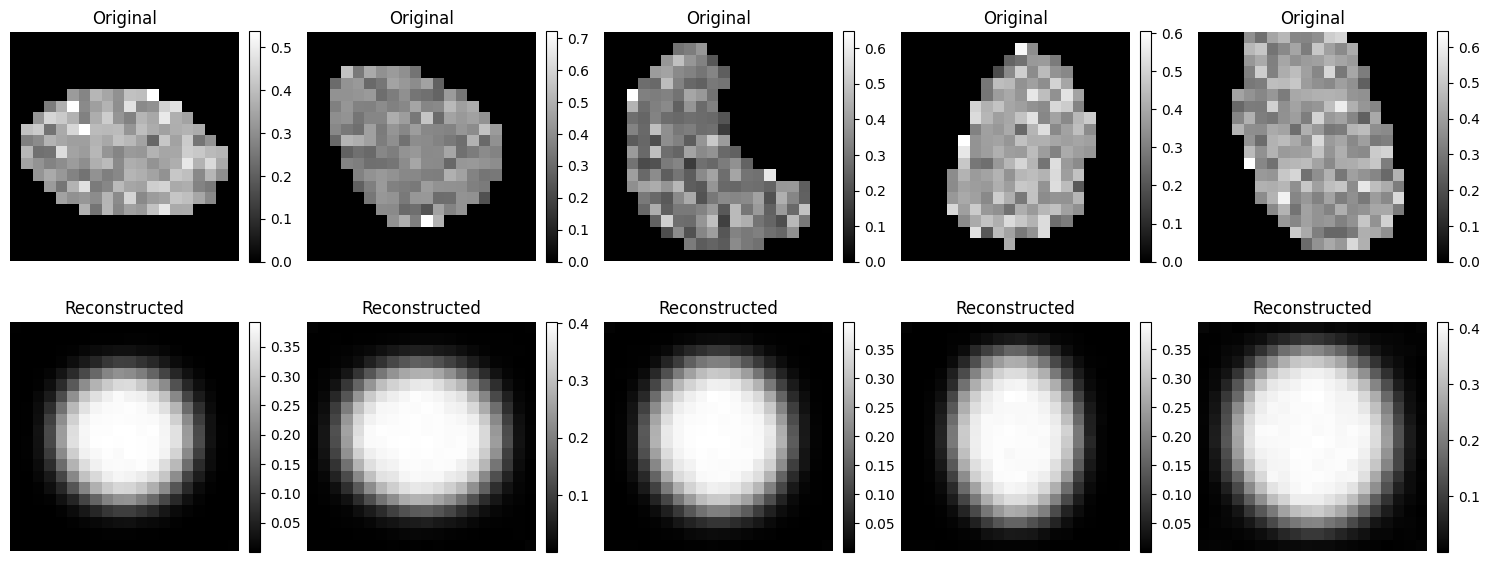

In [20]:
visualize_reconstructions(vae, data_loader, device)

Layer 'encoder.0' (Conv2d): active units = 155837
Layer 'encoder.1' (ReLU): active units = 155837
Layer 'encoder.2' (MaxPool2d): active units = 46125
Layer 'encoder.3' (Conv2d): active units = 23433
Layer 'encoder.4' (ReLU): active units = 23433
Layer 'encoder.5' (MaxPool2d): active units = 8424
Layer 'encoder.6' (Conv2d): active units = 12370
Layer 'encoder.7' (ReLU): active units = 12370
Layer 'encoder.8' (MaxPool2d): active units = 6861
Layer 'fc_mu' (Linear): active units = 31
Layer 'fc_logvar' (Linear): active units = 0
Layer 'encoder.0' (Conv2d): active units = 155073
Layer 'encoder.1' (ReLU): active units = 155073
Layer 'encoder.2' (MaxPool2d): active units = 45990
Layer 'encoder.3' (Conv2d): active units = 23476
Layer 'encoder.4' (ReLU): active units = 23476
Layer 'encoder.5' (MaxPool2d): active units = 8405
Layer 'encoder.6' (Conv2d): active units = 12573
Layer 'encoder.7' (ReLU): active units = 12573
Layer 'encoder.8' (MaxPool2d): active units = 7006
Layer 'fc_mu' (Linear): a

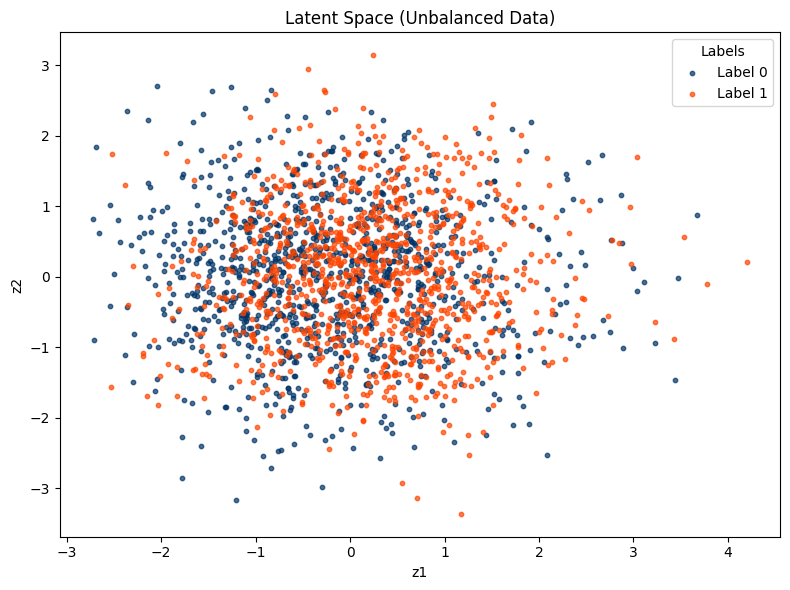

In [21]:
plot_full_latent_space(vae, data_loader, device=device)

In [22]:
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for images, label in data_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

X = np.vstack(latent_vectors)
y = np.hstack(labels)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
preds = clf.predict(X)

accuracy = accuracy_score(y, preds)
print(f"Logistic Regression Accuracy on Latent Space: {accuracy:.4f}")


Layer 'encoder.0' (Conv2d): active units = 156567
Layer 'encoder.1' (ReLU): active units = 156567
Layer 'encoder.2' (MaxPool2d): active units = 46433
Layer 'encoder.3' (Conv2d): active units = 23253
Layer 'encoder.4' (ReLU): active units = 23253
Layer 'encoder.5' (MaxPool2d): active units = 8378
Layer 'encoder.6' (Conv2d): active units = 12333
Layer 'encoder.7' (ReLU): active units = 12333
Layer 'encoder.8' (MaxPool2d): active units = 6884
Layer 'fc_mu' (Linear): active units = 34
Layer 'fc_logvar' (Linear): active units = 0
Layer 'encoder.0' (Conv2d): active units = 158264
Layer 'encoder.1' (ReLU): active units = 158264
Layer 'encoder.2' (MaxPool2d): active units = 45834
Layer 'encoder.3' (Conv2d): active units = 22958
Layer 'encoder.4' (ReLU): active units = 22958
Layer 'encoder.5' (MaxPool2d): active units = 8176
Layer 'encoder.6' (Conv2d): active units = 11838
Layer 'encoder.7' (ReLU): active units = 11838
Layer 'encoder.8' (MaxPool2d): active units = 6557
Layer 'fc_mu' (Linear): a

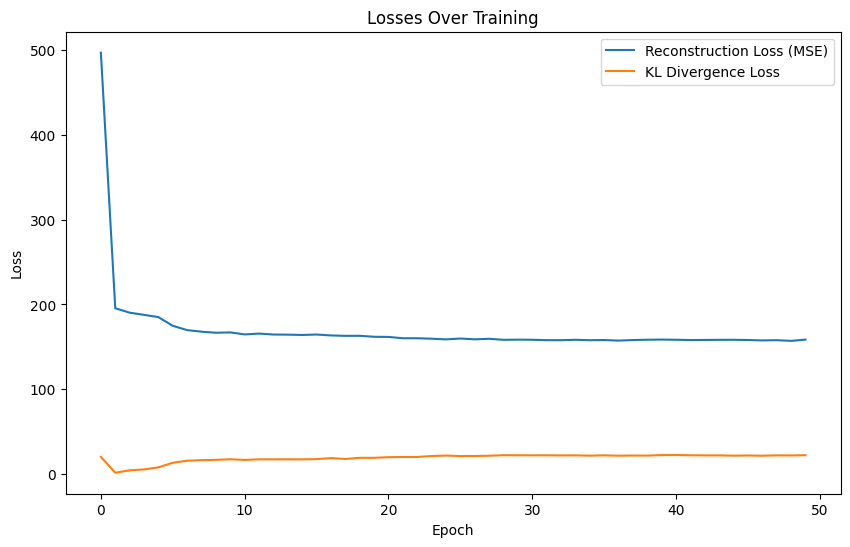

In [23]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

## MP3_128 with beta = 0.1 for reconstruction loss:

Layer 'encoder.0' (Conv2d): active units = 162644
Layer 'encoder.1' (ReLU): active units = 162644
Layer 'encoder.2' (MaxPool2d): active units = 48326
Layer 'encoder.3' (Conv2d): active units = 20293
Layer 'encoder.4' (ReLU): active units = 20293
Layer 'encoder.5' (MaxPool2d): active units = 6462
Layer 'encoder.6' (Conv2d): active units = 6786
Layer 'encoder.7' (ReLU): active units = 6786
Layer 'encoder.8' (MaxPool2d): active units = 3132
Layer 'fc_mu' (Linear): active units = 30
Layer 'fc_logvar' (Linear): active units = 28
Layer 'fc_decode' (Linear): active units = 18549
Layer 'decoder.0' (ConvTranspose2d): active units = 21058
Layer 'decoder.1' (ReLU): active units = 21058
Layer 'decoder.2' (ConvTranspose2d): active units = 40061
Layer 'decoder.3' (ReLU): active units = 40061
Layer 'decoder.4' (ConvTranspose2d): active units = 0
Layer 'decoder.5' (Sigmoid): active units = 12800


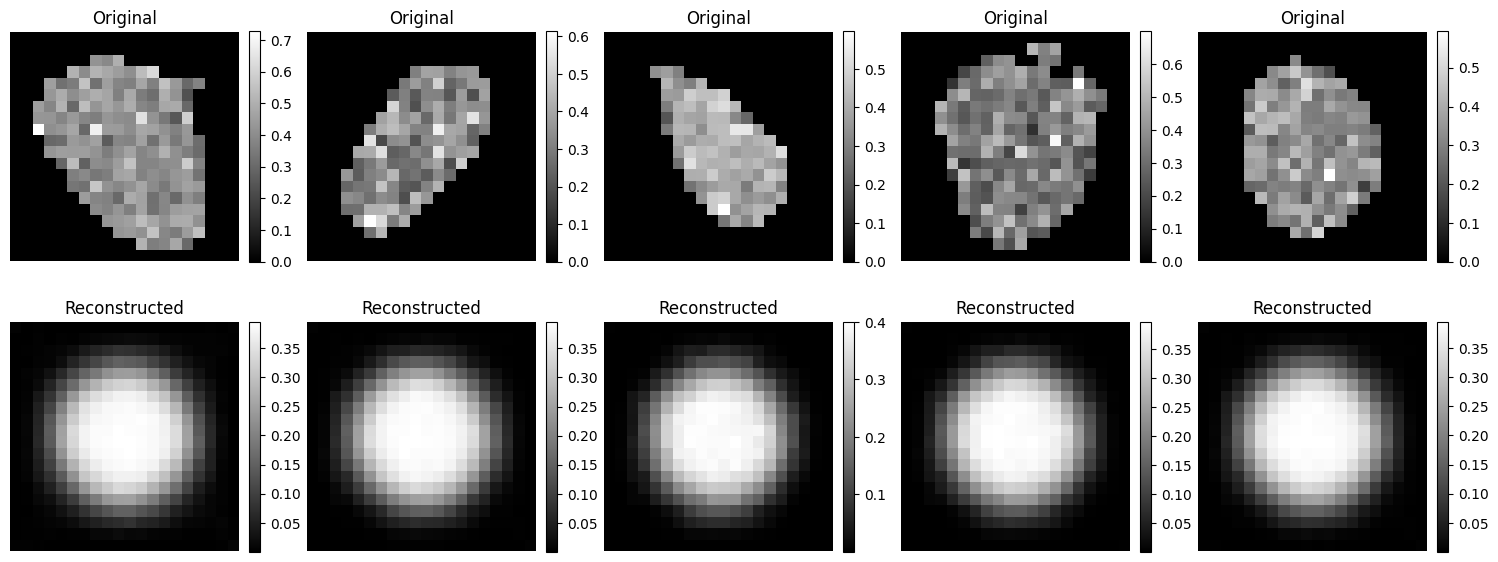

In [25]:
visualize_reconstructions(vae, data_loader, device)

Layer 'encoder.0' (Conv2d): active units = 163014
Layer 'encoder.1' (ReLU): active units = 163014
Layer 'encoder.2' (MaxPool2d): active units = 48165
Layer 'encoder.3' (Conv2d): active units = 20290
Layer 'encoder.4' (ReLU): active units = 20290
Layer 'encoder.5' (MaxPool2d): active units = 6429
Layer 'encoder.6' (Conv2d): active units = 6822
Layer 'encoder.7' (ReLU): active units = 6822
Layer 'encoder.8' (MaxPool2d): active units = 3159
Layer 'fc_mu' (Linear): active units = 33
Layer 'fc_logvar' (Linear): active units = 34
Layer 'encoder.0' (Conv2d): active units = 162591
Layer 'encoder.1' (ReLU): active units = 162591
Layer 'encoder.2' (MaxPool2d): active units = 48494
Layer 'encoder.3' (Conv2d): active units = 20294
Layer 'encoder.4' (ReLU): active units = 20294
Layer 'encoder.5' (MaxPool2d): active units = 6447
Layer 'encoder.6' (Conv2d): active units = 6939
Layer 'encoder.7' (ReLU): active units = 6939
Layer 'encoder.8' (MaxPool2d): active units = 3208
Layer 'fc_mu' (Linear): acti

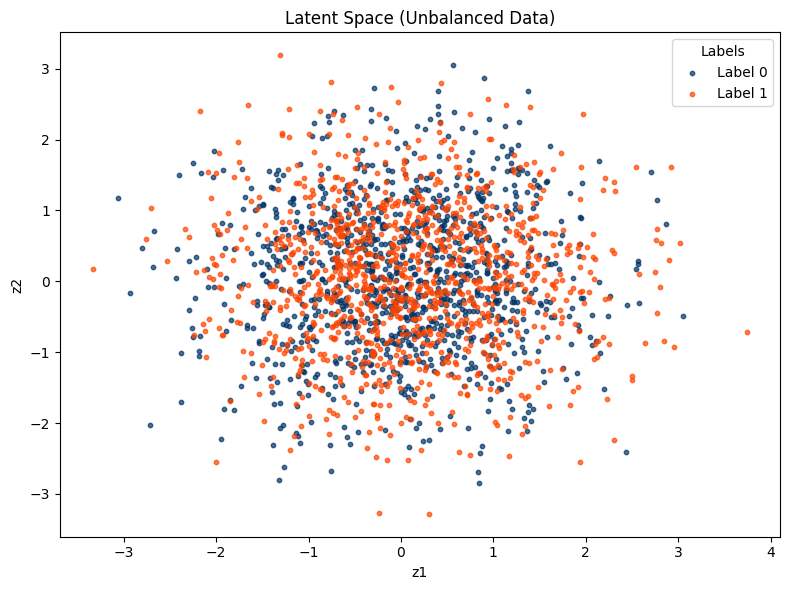

In [26]:
plot_full_latent_space(vae, data_loader, device=device)

In [27]:
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for images, label in data_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

X = np.vstack(latent_vectors)
y = np.hstack(labels)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
preds = clf.predict(X)

accuracy = accuracy_score(y, preds)
print(f"Logistic Regression Accuracy on Latent Space: {accuracy:.4f}")


Layer 'encoder.0' (Conv2d): active units = 162490
Layer 'encoder.1' (ReLU): active units = 162490
Layer 'encoder.2' (MaxPool2d): active units = 48114
Layer 'encoder.3' (Conv2d): active units = 20314
Layer 'encoder.4' (ReLU): active units = 20314
Layer 'encoder.5' (MaxPool2d): active units = 6464
Layer 'encoder.6' (Conv2d): active units = 6860
Layer 'encoder.7' (ReLU): active units = 6860
Layer 'encoder.8' (MaxPool2d): active units = 3181
Layer 'fc_mu' (Linear): active units = 23
Layer 'fc_logvar' (Linear): active units = 29
Layer 'encoder.0' (Conv2d): active units = 162863
Layer 'encoder.1' (ReLU): active units = 162863
Layer 'encoder.2' (MaxPool2d): active units = 48320
Layer 'encoder.3' (Conv2d): active units = 20139
Layer 'encoder.4' (ReLU): active units = 20139
Layer 'encoder.5' (MaxPool2d): active units = 6403
Layer 'encoder.6' (Conv2d): active units = 6835
Layer 'encoder.7' (ReLU): active units = 6835
Layer 'encoder.8' (MaxPool2d): active units = 3145
Layer 'fc_mu' (Linear): acti

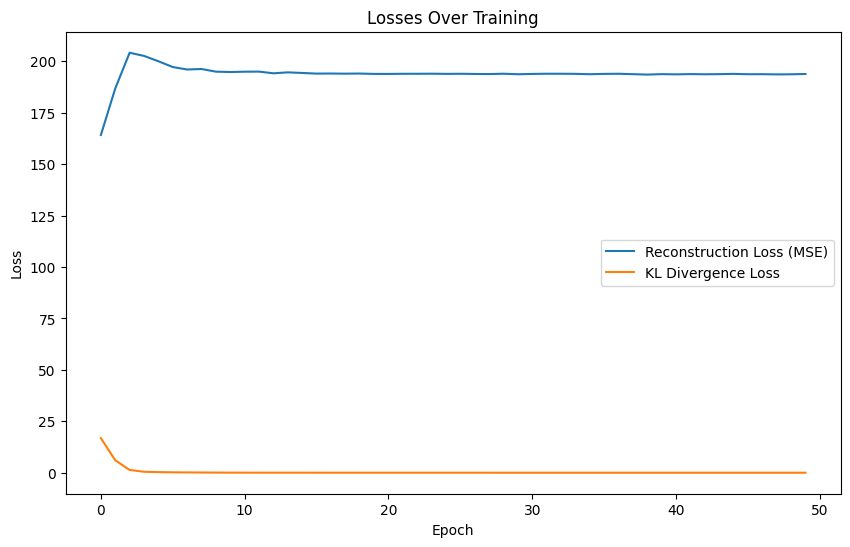

In [28]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

## Results with MP3_128 using beta = 0.2 for kl loss:

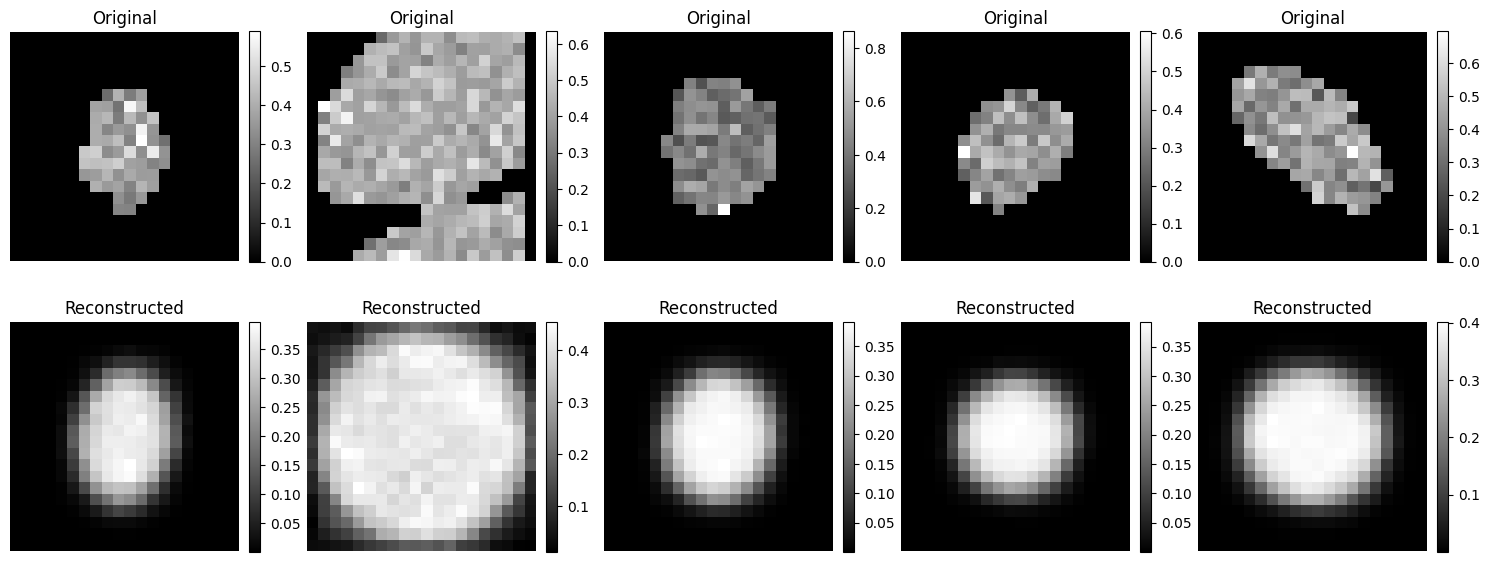

In [20]:
visualize_reconstructions(vae, data_loader, device)

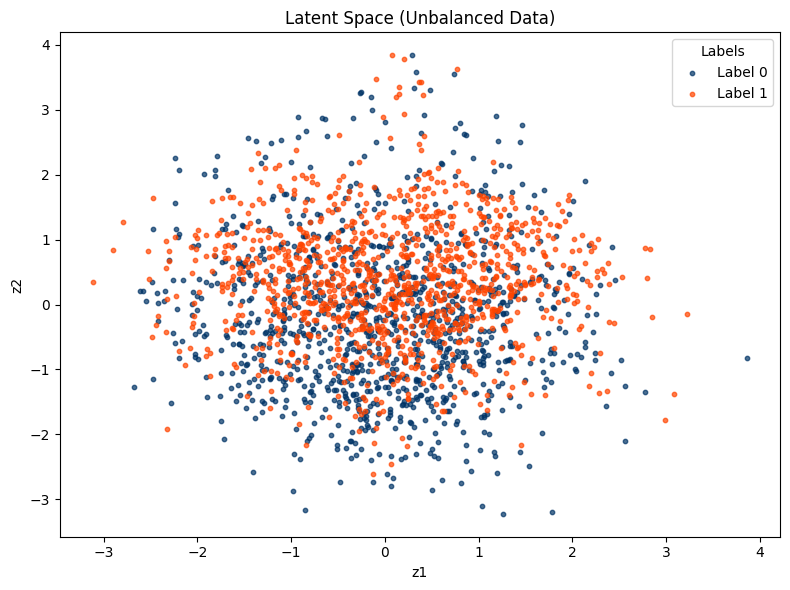

In [21]:
plot_full_latent_space(vae, data_loader, device=device)

In [22]:
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for images, label in data_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

X = np.vstack(latent_vectors)
y = np.hstack(labels)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
preds = clf.predict(X)

accuracy = accuracy_score(y, preds)
print(f"Logistic Regression Accuracy on Latent Space: {accuracy:.4f}")


Logistic Regression Accuracy on Latent Space: 0.6245


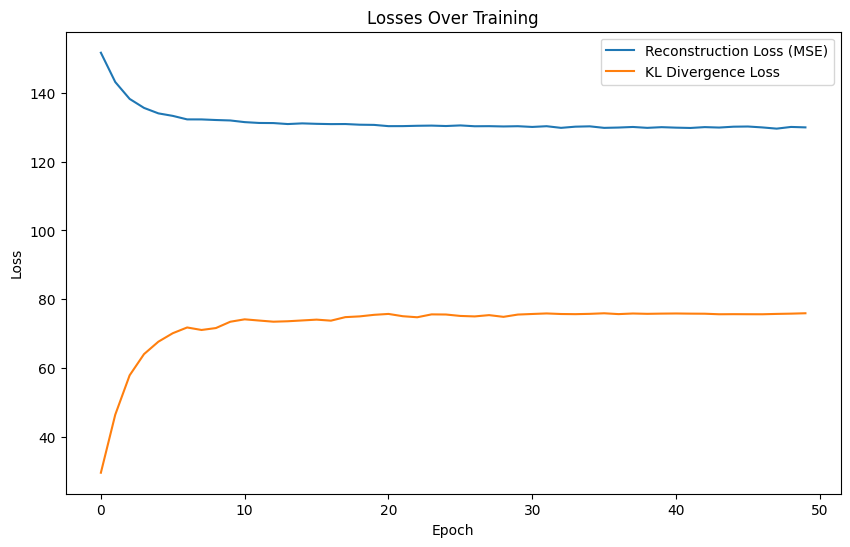

In [23]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

## MP3 with beta = 1, 50 epochs and doubled channel sizes in the VAE:

Layer 'encoder.0' (Conv2d): active units = 373522
Layer 'encoder.1' (ReLU): active units = 373522
Layer 'encoder.2' (MaxPool2d): active units = 106814
Layer 'encoder.3' (Conv2d): active units = 8284
Layer 'encoder.4' (ReLU): active units = 8284
Layer 'encoder.5' (MaxPool2d): active units = 2923
Layer 'encoder.6' (Conv2d): active units = 19678
Layer 'encoder.7' (ReLU): active units = 19678
Layer 'encoder.8' (MaxPool2d): active units = 11238
Layer 'fc_mu' (Linear): active units = 34
Layer 'fc_logvar' (Linear): active units = 0
Layer 'fc_decode' (Linear): active units = 37340
Layer 'decoder.0' (ConvTranspose2d): active units = 30957
Layer 'decoder.1' (ReLU): active units = 30957
Layer 'decoder.2' (ConvTranspose2d): active units = 70353
Layer 'decoder.3' (ReLU): active units = 70353
Layer 'decoder.4' (ConvTranspose2d): active units = 0
Layer 'decoder.5' (Sigmoid): active units = 12800


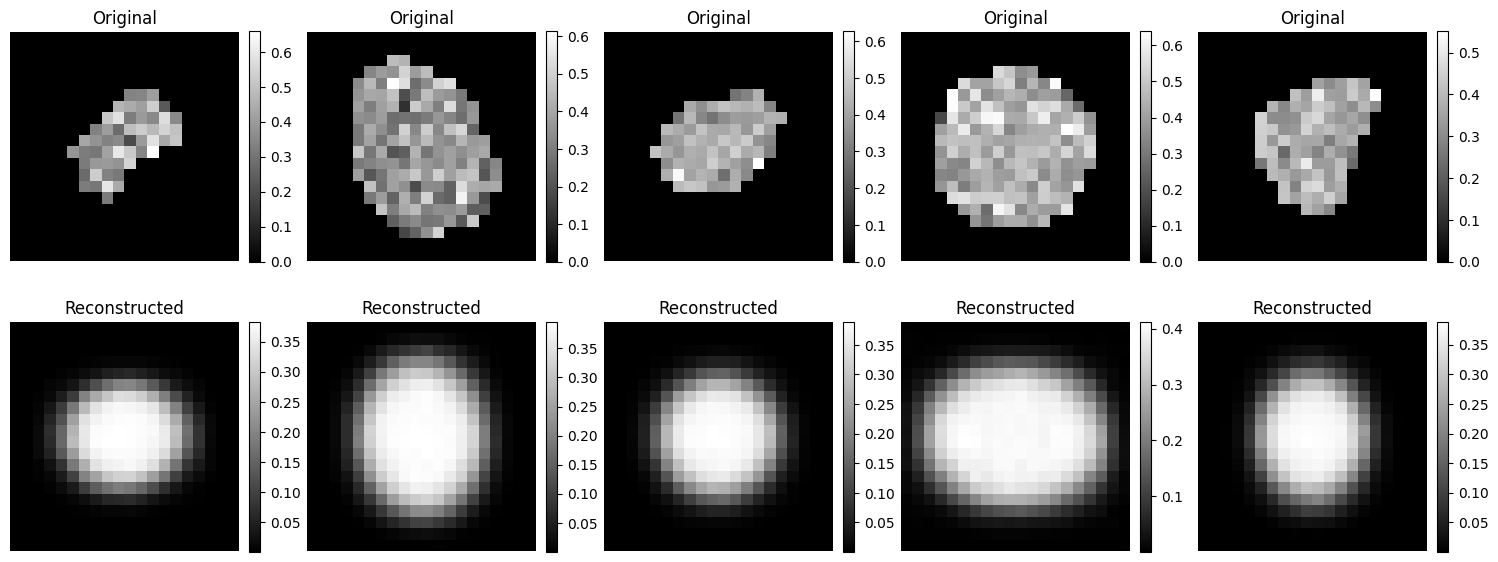

In [37]:
visualize_reconstructions(vae, data_loader, device)

Layer 'encoder.0' (Conv2d): active units = 372308
Layer 'encoder.1' (ReLU): active units = 372308
Layer 'encoder.2' (MaxPool2d): active units = 107429
Layer 'encoder.3' (Conv2d): active units = 8338
Layer 'encoder.4' (ReLU): active units = 8338
Layer 'encoder.5' (MaxPool2d): active units = 2968
Layer 'encoder.6' (Conv2d): active units = 20293
Layer 'encoder.7' (ReLU): active units = 20293
Layer 'encoder.8' (MaxPool2d): active units = 11369
Layer 'fc_mu' (Linear): active units = 36
Layer 'fc_logvar' (Linear): active units = 0
Layer 'encoder.0' (Conv2d): active units = 371659
Layer 'encoder.1' (ReLU): active units = 371659
Layer 'encoder.2' (MaxPool2d): active units = 107768
Layer 'encoder.3' (Conv2d): active units = 8411
Layer 'encoder.4' (ReLU): active units = 8411
Layer 'encoder.5' (MaxPool2d): active units = 2975
Layer 'encoder.6' (Conv2d): active units = 20679
Layer 'encoder.7' (ReLU): active units = 20679
Layer 'encoder.8' (MaxPool2d): active units = 11599
Layer 'fc_mu' (Linear): a

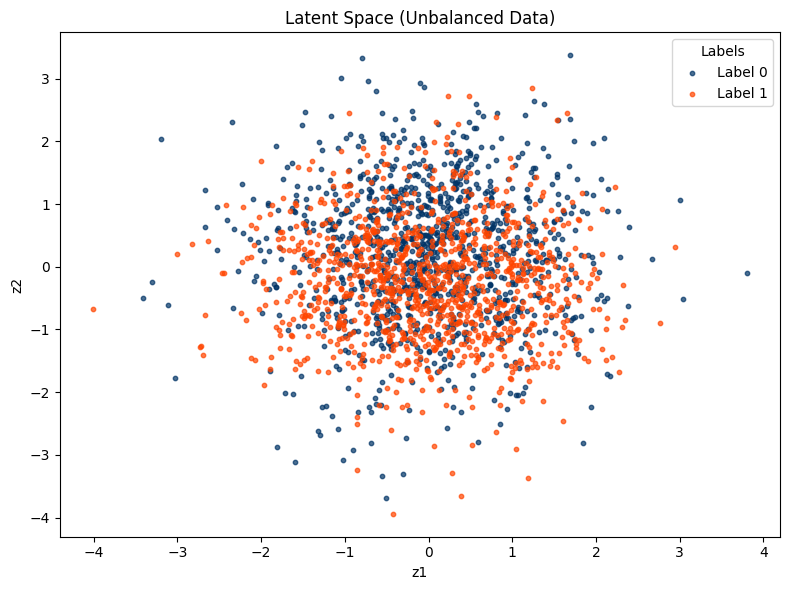

In [38]:
plot_full_latent_space(vae, data_loader, device=device)

In [39]:
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for images, label in data_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

X = np.vstack(latent_vectors)
y = np.hstack(labels)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
preds = clf.predict(X)

accuracy = accuracy_score(y, preds)
print(f"Logistic Regression Accuracy on Latent Space: {accuracy:.4f}")

Layer 'encoder.0' (Conv2d): active units = 372814
Layer 'encoder.1' (ReLU): active units = 372814
Layer 'encoder.2' (MaxPool2d): active units = 107258
Layer 'encoder.3' (Conv2d): active units = 8282
Layer 'encoder.4' (ReLU): active units = 8282
Layer 'encoder.5' (MaxPool2d): active units = 2931
Layer 'encoder.6' (Conv2d): active units = 19771
Layer 'encoder.7' (ReLU): active units = 19771
Layer 'encoder.8' (MaxPool2d): active units = 11427
Layer 'fc_mu' (Linear): active units = 33
Layer 'fc_logvar' (Linear): active units = 0
Layer 'encoder.0' (Conv2d): active units = 372088
Layer 'encoder.1' (ReLU): active units = 372088
Layer 'encoder.2' (MaxPool2d): active units = 106840
Layer 'encoder.3' (Conv2d): active units = 8312
Layer 'encoder.4' (ReLU): active units = 8312
Layer 'encoder.5' (MaxPool2d): active units = 2930
Layer 'encoder.6' (Conv2d): active units = 20133
Layer 'encoder.7' (ReLU): active units = 20133
Layer 'encoder.8' (MaxPool2d): active units = 11436
Layer 'fc_mu' (Linear): a

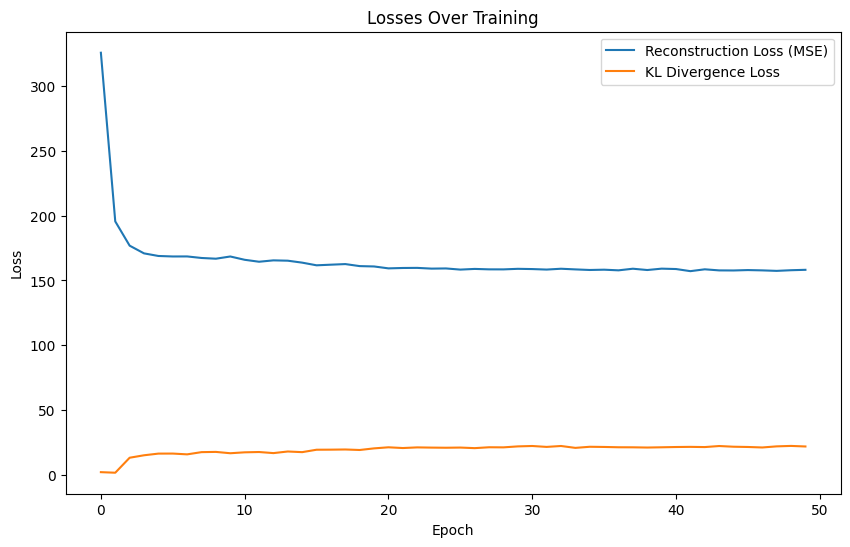

In [40]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

## Results with MP2:

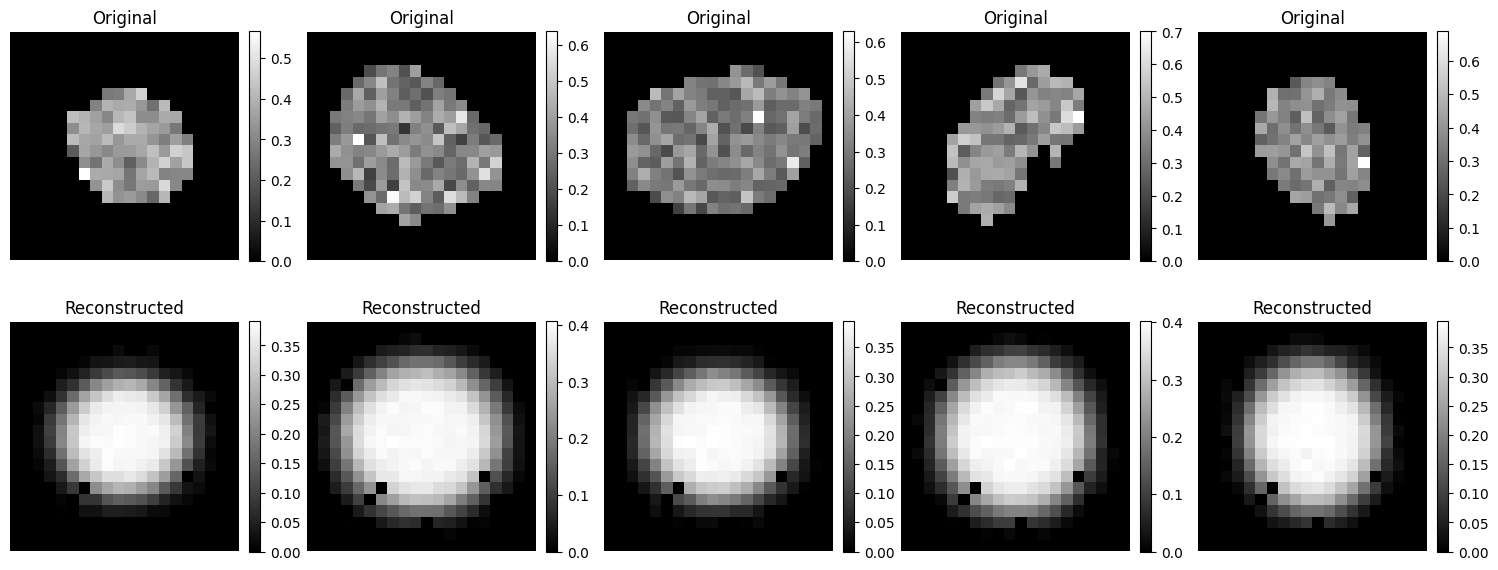

In [13]:
visualize_reconstructions(vae, data_loader, device)

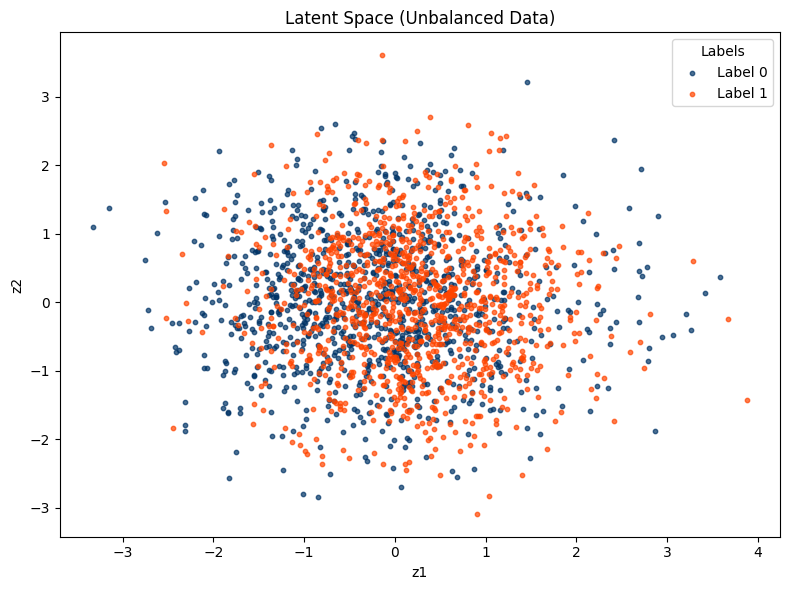

In [14]:
plot_full_latent_space(vae, data_loader, device=device)

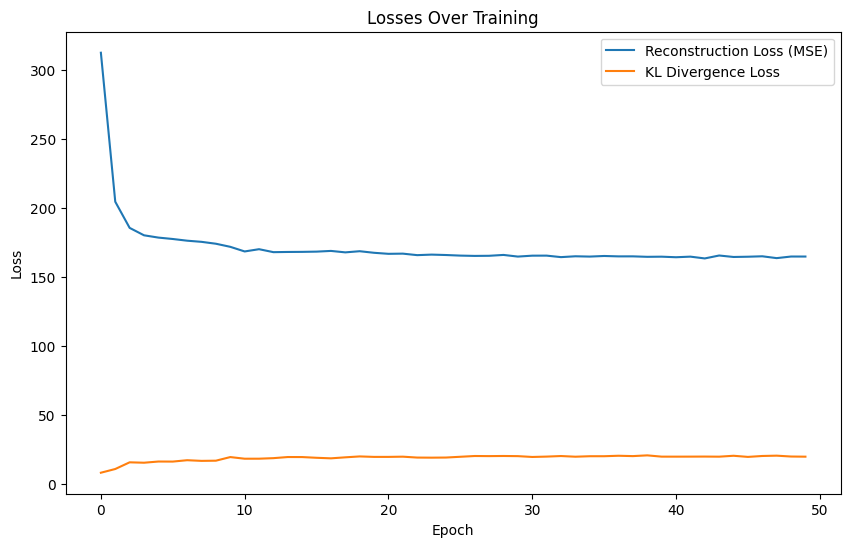

In [15]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

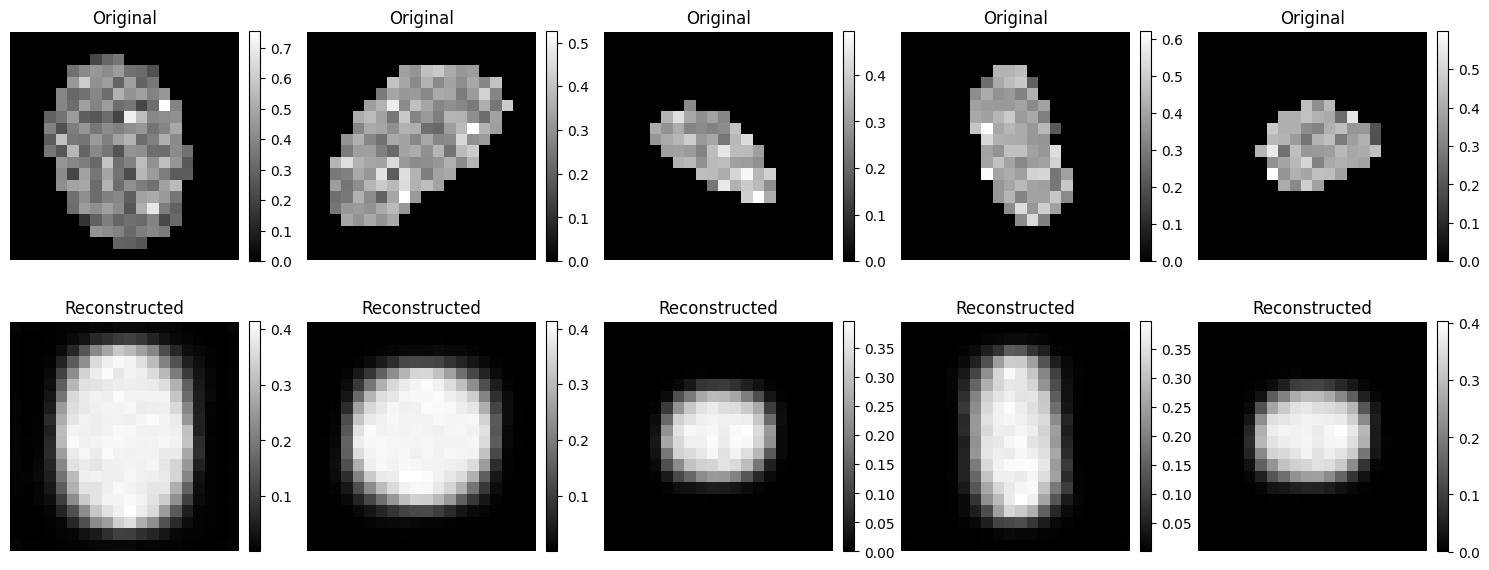

In [20]:
visualize_reconstructions(vae, data_loader, device)

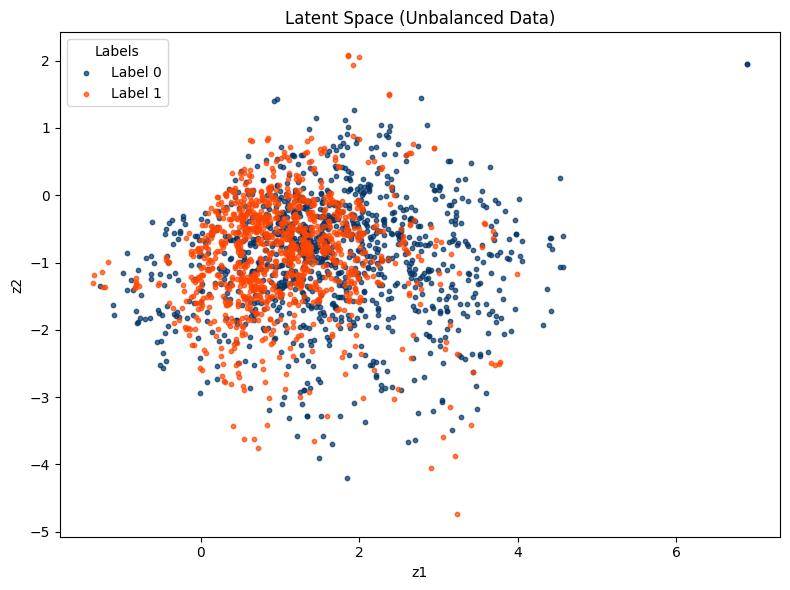

In [21]:
plot_full_latent_space(vae, data_loader, device=device)

In [22]:
vae.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for images, label in data_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(label.numpy())

X = np.vstack(latent_vectors)
y = np.hstack(labels)

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
preds = clf.predict(X)

accuracy = accuracy_score(y, preds)
print(f"Logistic Regression Accuracy on Latent Space: {accuracy:.4f}")


Logistic Regression Accuracy on Latent Space: 0.6470


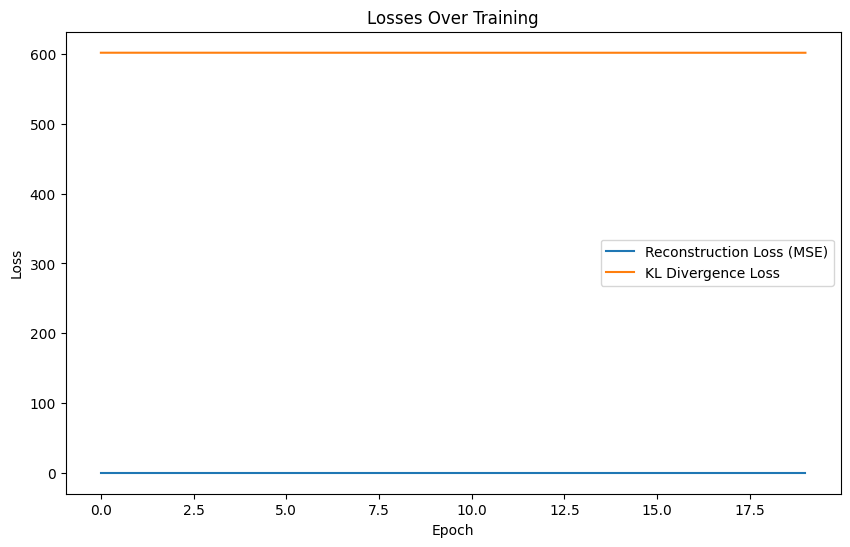

In [23]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

## MP2_64 for 50 epochs without loss scaling:

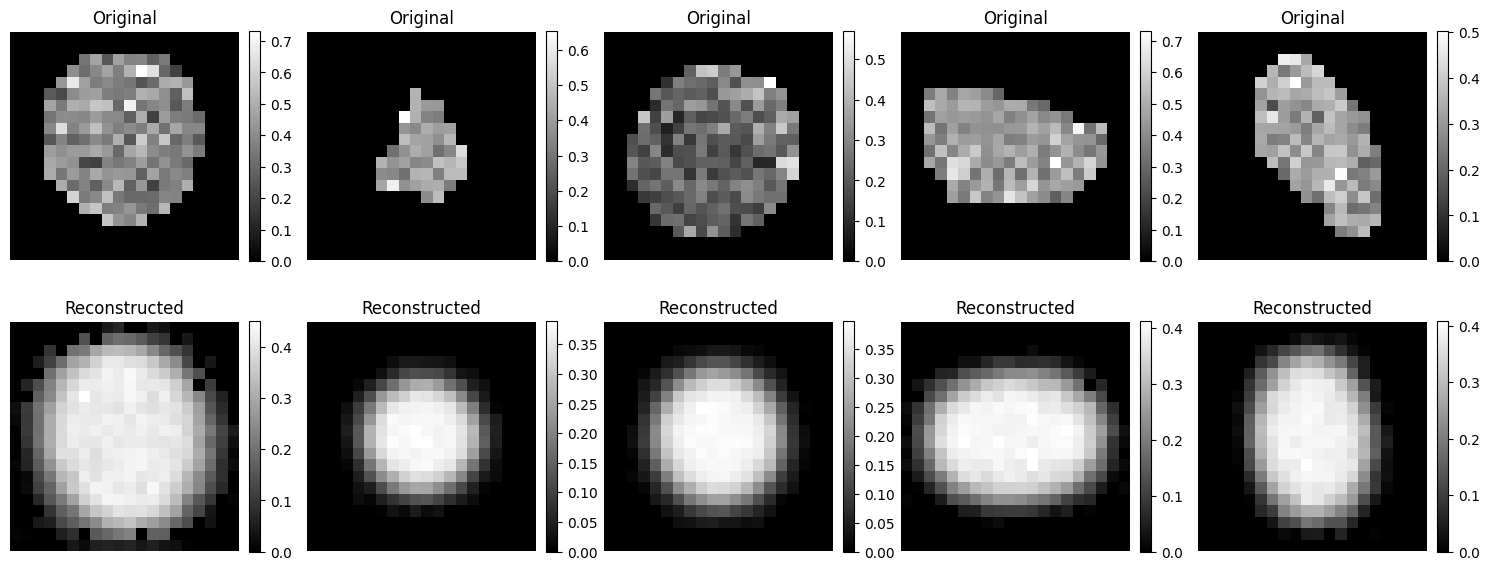

In [13]:
visualize_reconstructions(vae, data_loader, device)

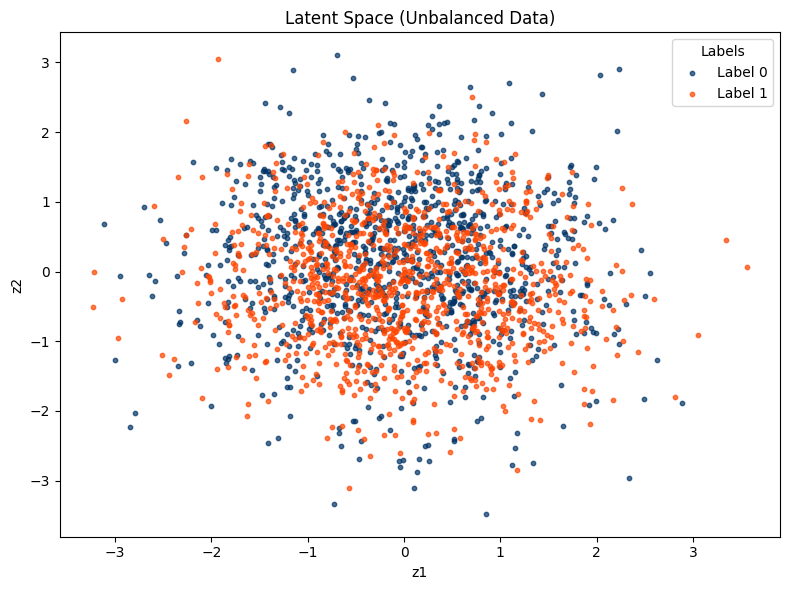

In [14]:
plot_full_latent_space(vae, data_loader, device=device)

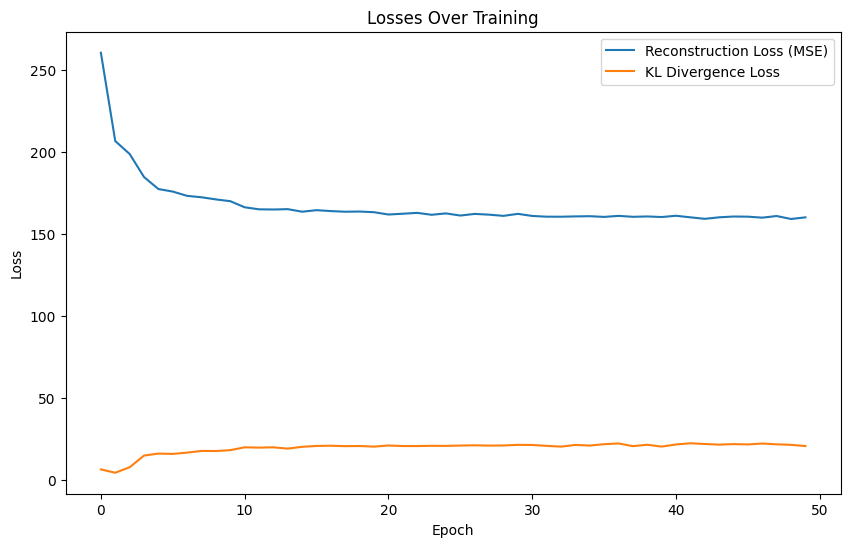

In [15]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

In [17]:
kl_losses

[0.3653540283009626,
 0.04972839960153552,
 0.03063592617062555,
 0.02414062878359919,
 0.0208286142003709,
 0.01467699546744858,
 0.007085506034934003,
 0.010894696781600731,
 0.004957407712936401,
 0.008295198281606039,
 0.0034703353176946225,
 0.001357554957486581,
 0.0012296166109002154,
 0.0009487154691115669,
 0.0043103690596594324,
 0.0008814896362415259,
 0.0015977595163428266,
 0.0006864278212837551,
 0.0009043868901073068,
 0.0006613109422766644,
 0.0005588591962620832,
 0.0002815248309702113,
 0.00022252573483232138,
 0.00023003289665001026,
 0.00035769913507544476,
 0.0002471174018970434,
 0.00026651525842970693,
 0.0002733464690222256,
 0.00017022827397222105,
 0.00020497821379398954,
 0.00019852406736733258,
 0.00010073228158812591,
 7.05468481865482e-05,
 6.668895914934683e-05,
 7.885608120241027e-05,
 0.00010694412217623946,
 9.22239345052968e-05,
 0.0001420611920564071,
 0.00011925636858179949,
 0.00015392251636670983,
 0.00012087994727535525,
 0.0001294366691423499,
 

## MP2_128 for 50 epochs without loss scaling:

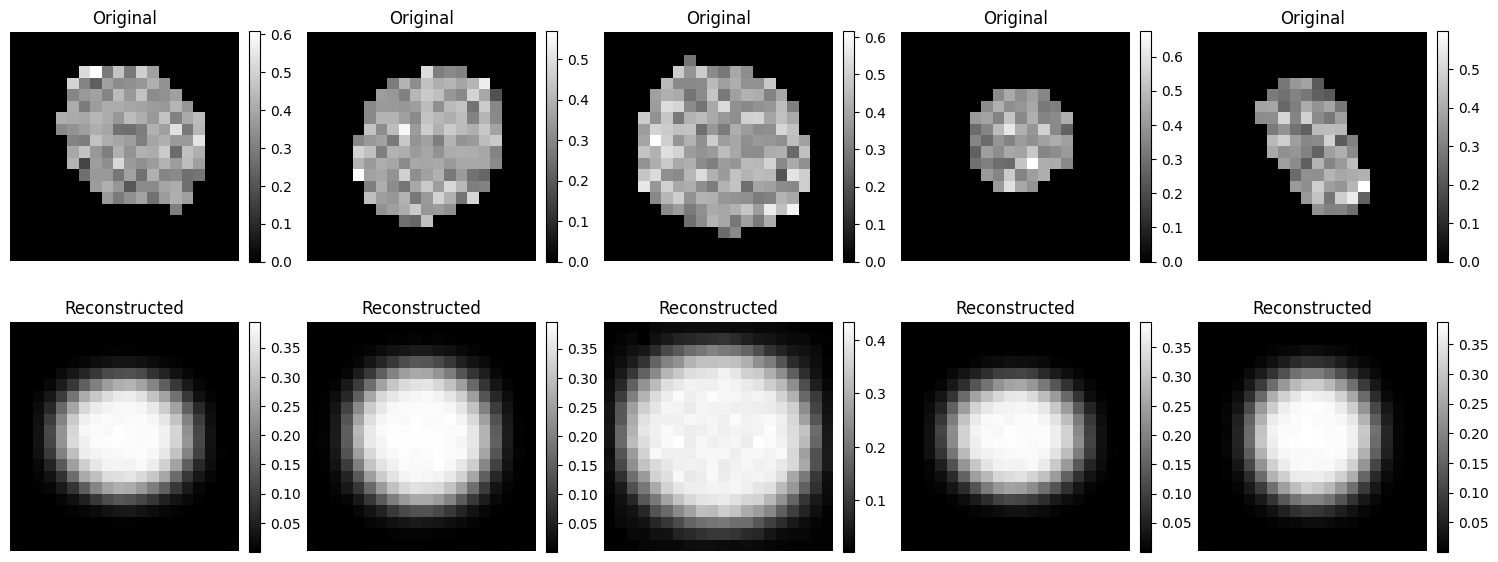

In [13]:
visualize_reconstructions(vae, data_loader, device)

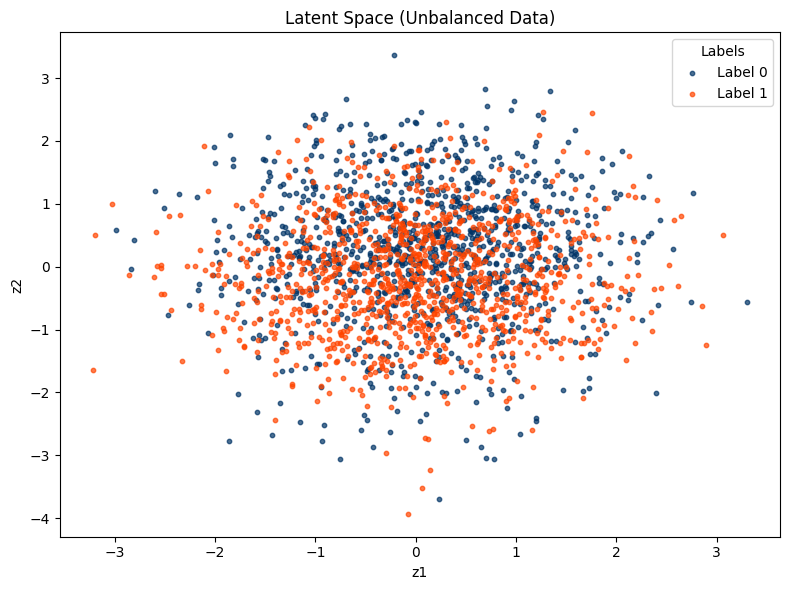

In [14]:
plot_full_latent_space(vae, data_loader, device=device)

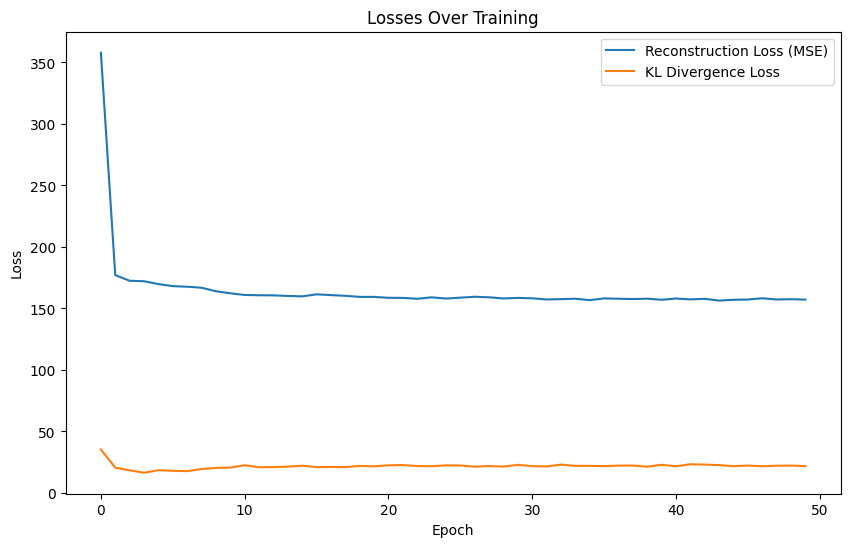

In [15]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

### MP2_128 for 50 epochs with 0.5 kl_loss sclaing:

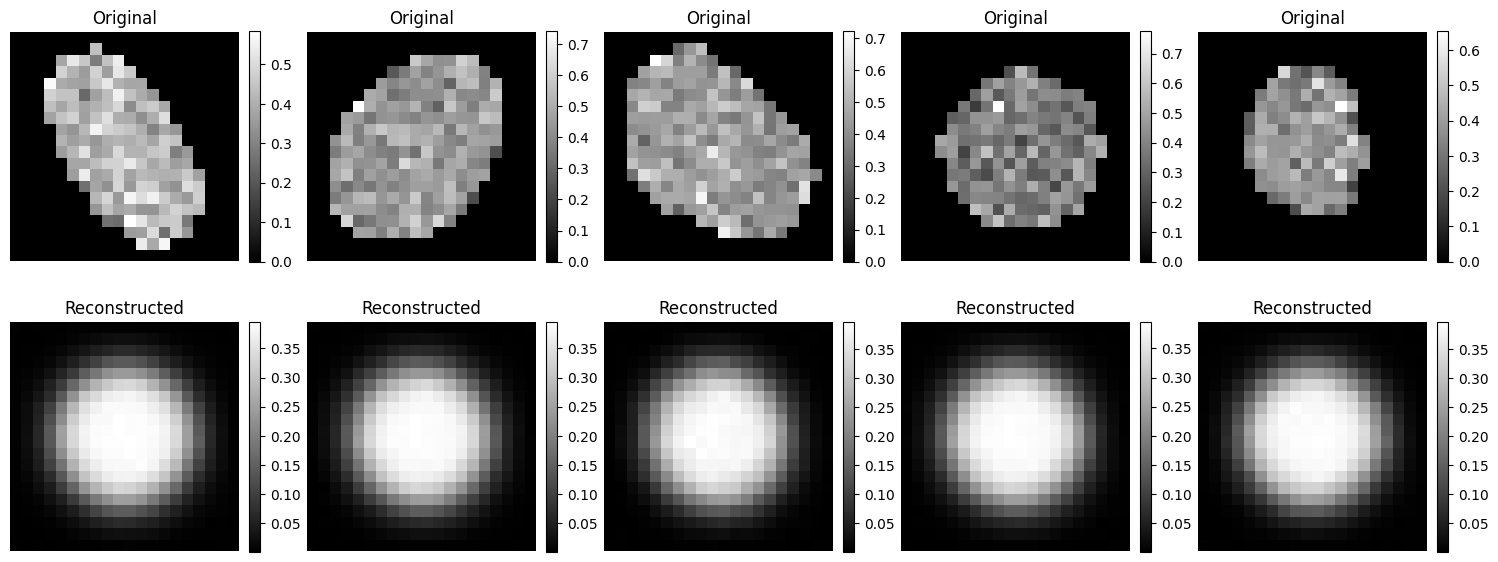

In [13]:
visualize_reconstructions(vae, data_loader, device)

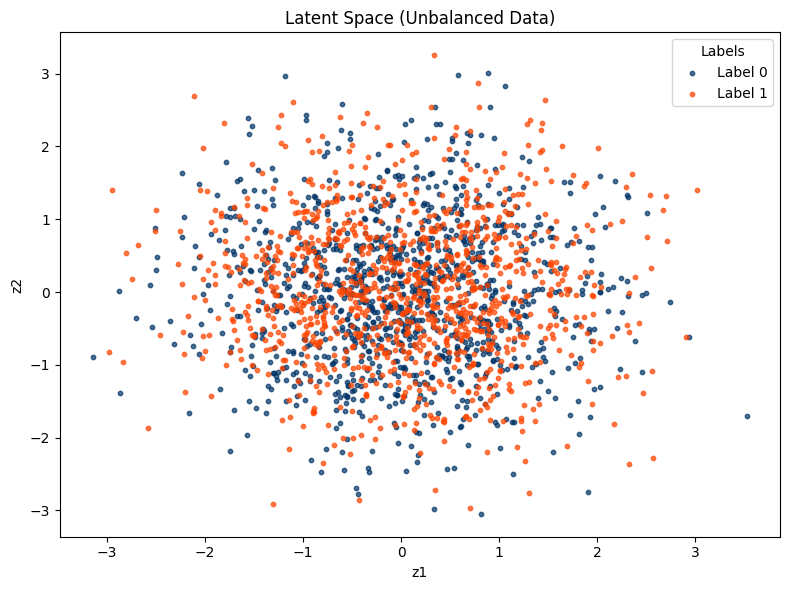

In [14]:
plot_full_latent_space(vae, data_loader, device=device)

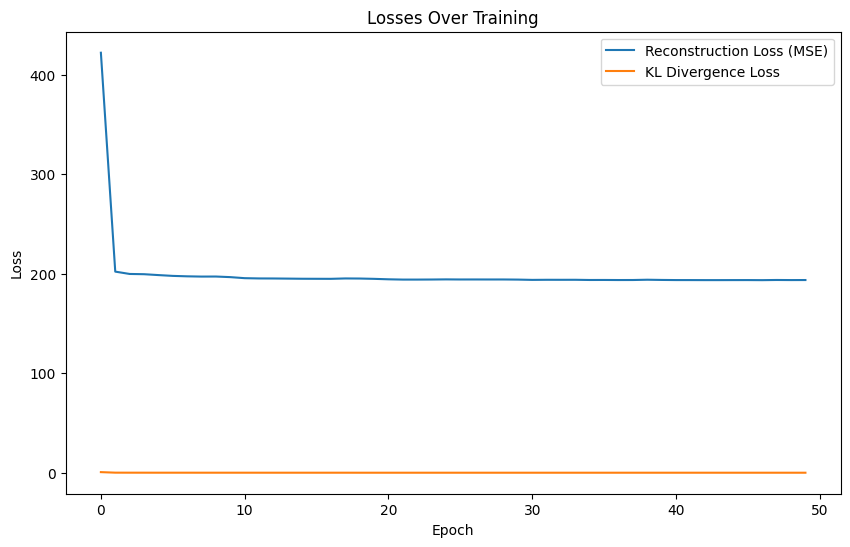

In [16]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

In [18]:
reconstruction_losses

[422.0762753141099,
 202.09502643087635,
 199.74795338727426,
 199.49878703684047,
 198.61584749083588,
 197.80260555986044,
 197.36695900516233,
 197.10957966680112,
 197.16175610086194,
 196.56195245272872,
 195.51331075032553,
 195.24350274127463,
 195.19817689536274,
 195.06892914702928,
 194.92467515364936,
 194.8841301738352,
 194.84926936937416,
 195.23315551315528,
 195.1487665038178,
 194.83024458954299,
 194.3714759937231,
 194.0883606067602,
 194.0910386900971,
 194.158664095229,
 194.29203553130662,
 194.19412485758463,
 194.20860765982366,
 194.19100377179575,
 194.20009983449742,
 194.0820524243341,
 193.7887964663298,
 193.88939086250636,
 193.86858843374944,
 193.89019006922626,
 193.68531196704808,
 193.71315881480342,
 193.63879626730213,
 193.66379397848377,
 193.94570607724398,
 193.7343958426213,
 193.60574561962184,
 193.59462516895238,
 193.55737122245458,
 193.56063649274301,
 193.58759954701299,
 193.5986621690833,
 193.52183886541837,
 193.69135544265527,
 193

### MP2_138 for 50 epoch with 0.1 reconstruction loss scale:

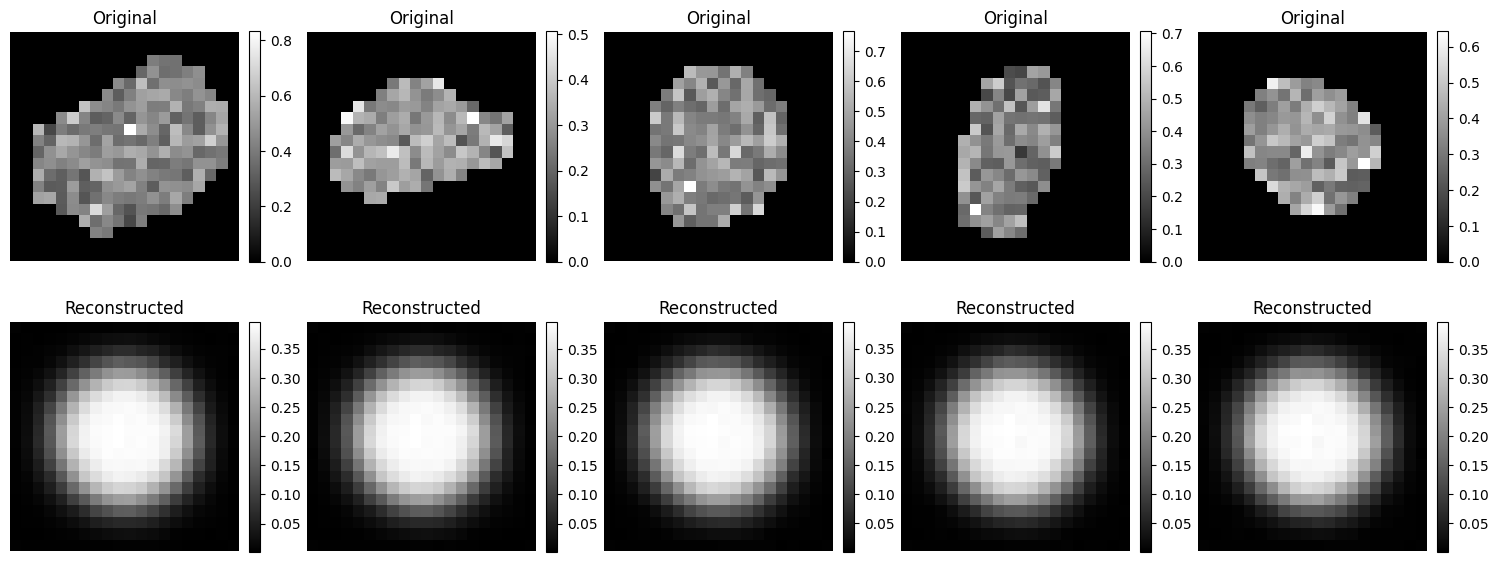

In [13]:
visualize_reconstructions(vae, data_loader, device)

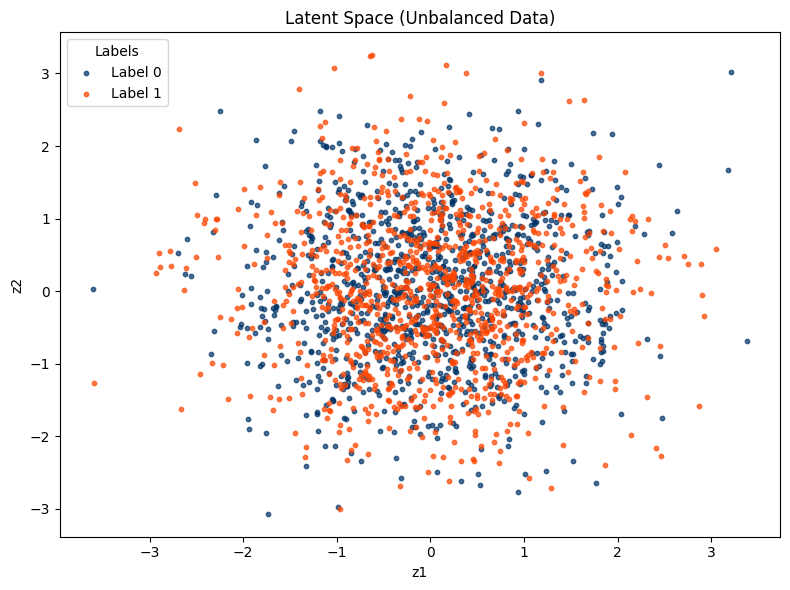

In [14]:
plot_full_latent_space(vae, data_loader, device=device)

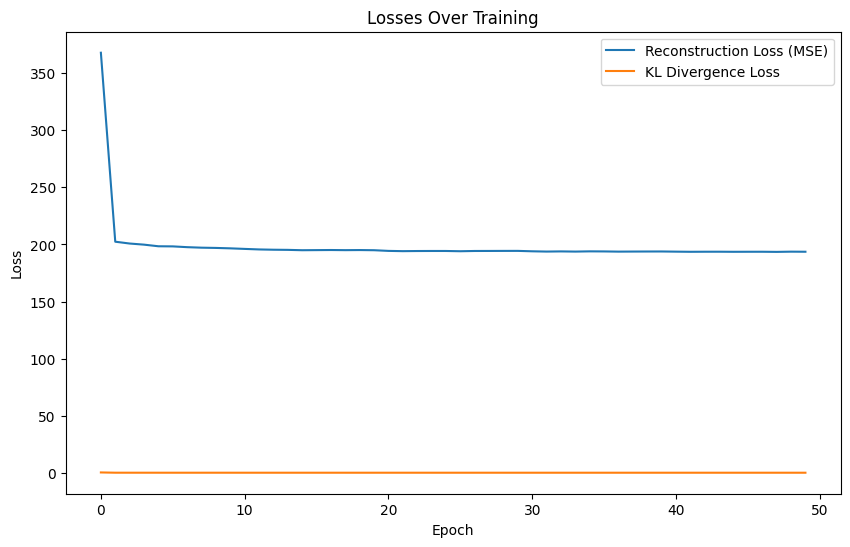

In [ ]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()

### MP2_128 for 50 epochs with 0.1 reconstruction loss and 10.0 kl loss sclaeing:

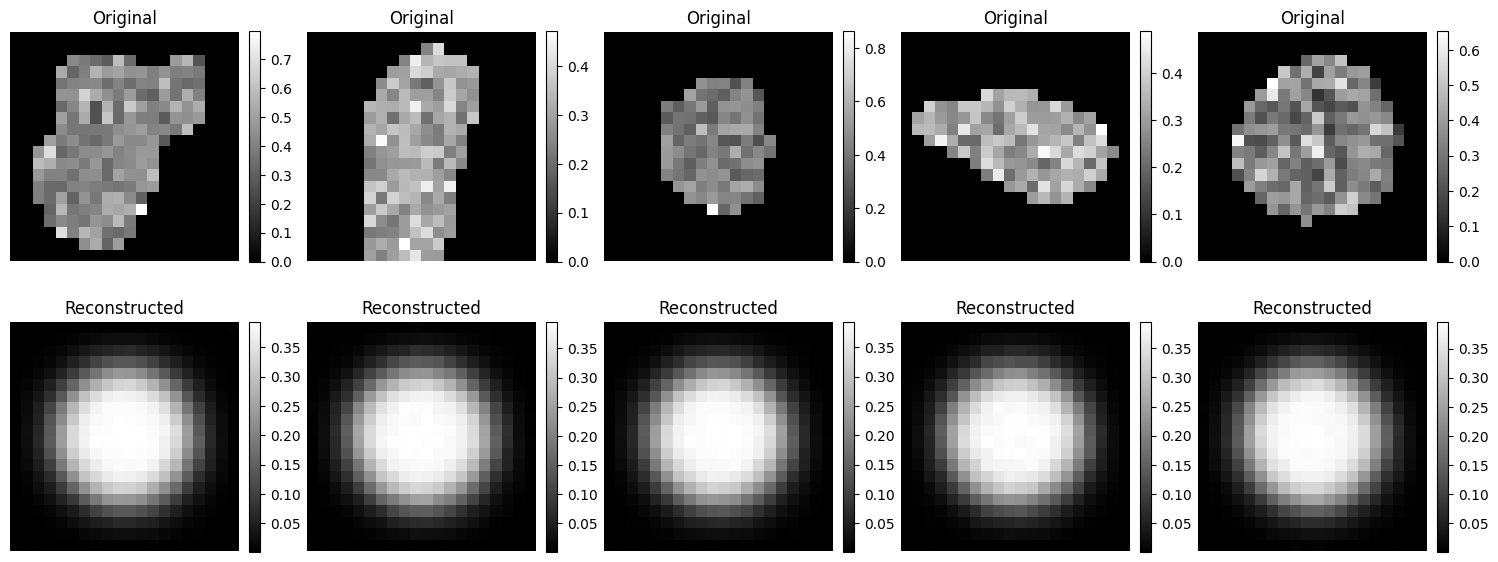

In [14]:
visualize_reconstructions(vae, data_loader, device)

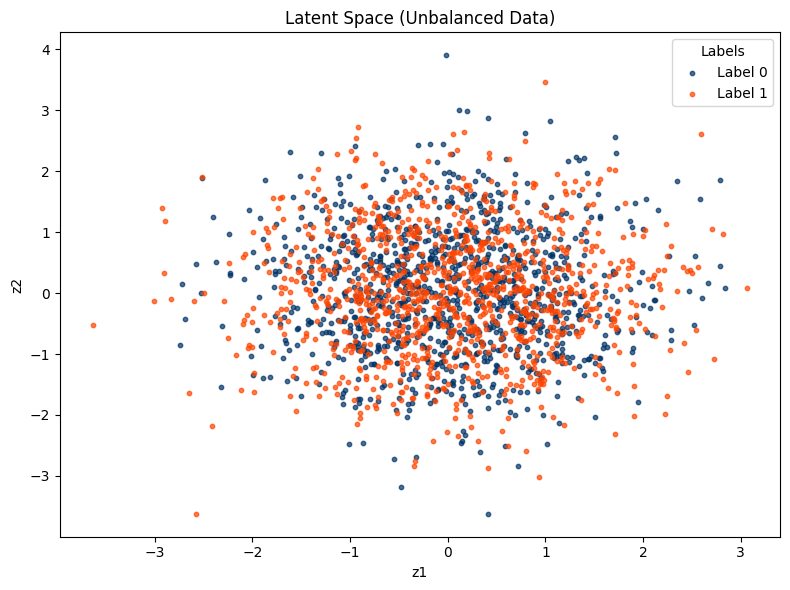

In [15]:
plot_full_latent_space(vae, data_loader, device=device)

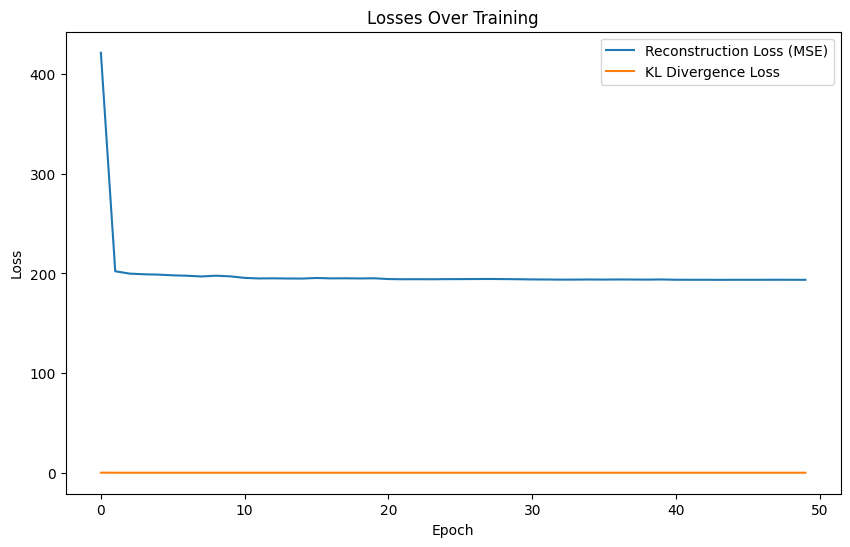

In [16]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()